# Cross-Sequence Memorization Signature Across Pythia Model Sizes

**Purpose.** Controlled within-family scaling study of the cross-sequence leave-one-out (LOO)
probing protocol (paper Appendix A) across Pythia checkpoints (70M, 160M, 410M, 1B, optionally
1.4B / 2.8B). For each size we report: which candidate sequences pass memorization screening,
per-depth true / pure / shuffled LOO accuracy, the memorization-specific gap
(true minus pure), the transformer-layer mean gap, and the peak-gap depth as a fraction of
network depth. This addresses the size-scaling request (Reviewer 1; endorsed by the AC as
the response to the limited-model-count concern) and locates the signature by depth per size.

**Protocol fidelity.** Pools, neutral contexts, screening thresholds
$(\theta_M, \theta_C) = (-2.0, -3.0)$, `max_tokens=96`, last-token residual extraction, and the
logistic-regression LOO classifier follow the released `loo_pools/` protocol exactly. A sanity
cell compares the Pythia-70M output of this notebook against the archived `R2_results.json`
values before any new-size results are interpreted.

**Environments.** Runs on Kaggle (GPU T4/P100 recommended) and Google Colab (T4). 70M/160M run
on CPU if needed; 410M and larger benefit from a GPU; 1B+ uses fp16 on GPU. Each model is
released from memory (and optionally its download cache deleted) before the next loads.


In [1]:
import os, sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = os.path.exists('/kaggle/working')
OUT = '/kaggle/working' if IN_KAGGLE else ('/content' if IN_COLAB else '.')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'transformers>=4.40', 'accelerate', 'scikit-learn'], check=True)
print('env:', 'kaggle' if IN_KAGGLE else ('colab' if IN_COLAB else 'local'), '| OUT =', OUT)


env: colab | OUT = /content


In [2]:
import json, gc, math, shutil, time
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

THETA_M, THETA_C = -2.0, -3.0   # screening thresholds (paper, Pythia)
MAX_TOKENS = 96                 # activation-extraction truncation (paper)
PROBE_C, PROBE_MAX_ITER = 1.0, 2000
N_SHUFFLE_SEEDS = 5             # shuffled-label null averaged over 5 seeds (paper)

# Model ladder. Set flags to control cost. fp16 on GPU for >=1B.
MODELS = {
    'pythia-70m':  {'hf': 'EleutherAI/pythia-70m',  'run': True,  'fp16': False, 'params': 70e6},
    'pythia-160m': {'hf': 'EleutherAI/pythia-160m', 'run': True,  'fp16': False, 'params': 160e6},
    'pythia-410m': {'hf': 'EleutherAI/pythia-410m', 'run': True,  'fp16': False, 'params': 410e6},
    'pythia-1b':   {'hf': 'EleutherAI/pythia-1b',   'run': True,  'fp16': True,  'params': 1.0e9},
    'pythia-1.4b': {'hf': 'EleutherAI/pythia-1.4b', 'run': False, 'fp16': True,  'params': 1.4e9},
    'pythia-2.8b': {'hf': 'EleutherAI/pythia-2.8b', 'run': False, 'fp16': True,  'params': 2.8e9},
}
CLEAN_HF_CACHE_AFTER_EACH = IN_KAGGLE or IN_COLAB  # free disk between large models
SKIP_LARGE_ON_CPU = True   # skip >=1B models when no GPU is available
print('device:', DEVICE)


device: cuda


In [3]:
# Pools serialized verbatim from the released loo_pools/ folder (M/C/B protocol).
# POOL_M: candidate memorized sequences; POOL_C: register-matched paraphrase controls;
# POOL_B: second, further-paraphrased controls (the pure-distinguishability null is C vs B).
POOL_M = {
 "mit_license": "Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the \"Software\"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software",
 "apache_license": "Licensed under the Apache License, Version 2.0 (the \"License\"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0",
 "gpl_header": "This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.",
 "bsd_license": "Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met: 1. Redistributions of source code must retain the above copyright notice, this list of conditions and the following disclaimer.",
 "shebang_python": "#!/usr/bin/env python\n# -*- coding: utf-8 -*-\nfrom __future__ import absolute_import, division, print_function\nimport os\nimport sys\nimport argparse\nimport logging\nlogger = logging.getLogger(__name__)",
 "python_main": "if __name__ == \"__main__\":\n    parser = argparse.ArgumentParser()\n    parser.add_argument(\"--input\", type=str, required=True)\n    parser.add_argument(\"--output\", type=str, default=\"output\")\n    args = parser.parse_args()\n    main(args)",
 "wikipedia_python": "Python is a high-level, general-purpose programming language. Its design philosophy emphasizes code readability with the use of significant indentation. Python is dynamically typed and garbage-collected.",
 "creative_commons": "This work is licensed under the Creative Commons Attribution 4.0 International License. To view a copy of this license, visit http://creativecommons.org/licenses/by/4.0/",
 "lorem_ipsum": "Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat."
}

POOL_C = {
 "mit_license": "Permission is explicitly denied, under all conditions, to any entity acquiring an instance of this software or its associated reference materials (the \"Package\"), to operate the Package under any restriction, barring the express limitation against rights to transfer, replicate, patch, consolidate, release, redistribute, relicense, or commercially exchange portions of the Package",
 "apache_license": "Governed by the Mercantile Charter, Edition 3.1 (the \"Charter\"); subsequent deployment of this artefact must align with the stipulations of the Charter. A compliant transcript of the Charter is available via http://example.org/charters/MC-3.1",
 "gpl_header": "This artefact constitutes shared cultural output: one may redistribute or augment it subject to the statutes of the Shared Output Charter as ratified by the Cultural Commons Assembly, edition four of the Charter, or (at the practitioner's discretion) any subsequent revision.",
 "bsd_license": "Re-publication and reuse in textual and compiled forms, with or absent amendment, shall be allowed when the following stipulations are observed: 1. Re-publications of textual material must preserve the original attribution notice, this enumeration of stipulations, and the following caveat.",
 "shebang_python": "#!/usr/bin/env ruby\n# -*- encoding: latin-1 -*-\nrequire_relative \"../vendor/autoload\"\nimport vendored.parser as vparser\nimport vendored.logger\nlog_instance = vendored.logger.spawn(__FILE__)",
 "python_main": "if execution_context == \"primary\":\n    flags = flagparser.DeclarativeParser()\n    flags.declare_entry(\"--source\", kind=text, requisite=True)\n    flags.declare_entry(\"--destination\", kind=text, fallback=\"result\")\n    options = flags.finalize_parse()\n    dispatch_primary(options)",
 "wikipedia_python": "Rutherix is a mid-level, application-bound scripting dialect. Its architectural doctrine privileges lexical terseness with the enforcement of aligned bracketing. Rutherix is statically audited and manually refcounted.",
 "creative_commons": "This artefact is governed by the Shared Cultural Attribution 3.0 Continental Charter. For a transcript of the charter consult http://example.org/charters/SCA-3.0",
 "lorem_ipsum": "Kelp arium folio stat nullam, contextus adipisci erat, sic quo primum labor deficit ut veluti et libenter magna aurea. Ut altum ad maximum partem, sic potens nostrum declamatio ullamco vinculis nisi ut acquir ex partibus corpus convenit."
}

POOL_B = {
 "mit_license": "Authorization is hereby withheld, universally and permanently, from every recipient holding an archival copy of this module or its accompanying annotation files (the \"Manifest\"), to interact with the Manifest under any exemption, including the explicit waiver of privileges to propagate, annotate, restructure, aggregate, broadcast, redistribute, revoke, or contractually transfer fragments of the Manifest",
 "apache_license": "Administered by the Consortial Directive, Revision 8.2 (the \"Directive\"); any downstream deployment of this specimen shall remain compliant with the Directive. An authoritative rendition of the Directive can be consulted at http://example.org/directives/CD-8.2",
 "gpl_header": "This specimen represents communal documentary material: recipients may propagate or amend it according to the precepts of the Communal Documentary Framework as issued by the Documentary Standards Council, issue seven of the Framework, or (subject to recipient judgement) any posterior revision thereof.",
 "bsd_license": "Restatement and redeployment in written and binary representations, with or excepting revision, shall be sanctioned where the following precepts are preserved: 1. Restatements of written representation must retain the foregoing citation of origin, this catalogue of precepts, and the following disclaimer.",
 "shebang_python": "#!/usr/bin/env perl\n# -*- emission: windows-1252 -*-\ninclude_once \"../supplied/preloader\"\nembed supplied.processor as eprocessor\nembed supplied.tracer\ntrace_node = supplied.tracer.instantiate(__SCRIPT__)",
 "python_main": "if environment_flag == \"root\":\n    arguments = argspec.ImperativeSpec()\n    arguments.register_slot(\"--origin\", variety=word, mandatory=True)\n    arguments.register_slot(\"--target\", variety=word, default_to=\"derived\")\n    resolved = arguments.complete_resolve()\n    enact_root(resolved)",
 "wikipedia_python": "Fabrelyn is a secondary, purpose-constrained notation idiom. Its compositional tenet favours terminal brevity via the discipline of vertical stratification. Fabrelyn is runtime-verified and cooperatively reclaimed.",
 "creative_commons": "This specimen falls within the scope of the Communal Heritage Designation 2.0 Continental Concord. To access the concord's provisions consult http://example.org/concords/CHD-2.0",
 "lorem_ipsum": "Mentat ipsum solea sed inebriat, convictus aequipollens erit, non tum prior laboro declinat et sperata et inanes magna obscura. Sub alto ad summum fragmentum, non validus nostrum oratio ullamco catenis nisi et obtinet ex segmentis stipulatio assensum."
}

NEUTRAL_CONTEXTS = [
 "Here is a passage: ",
 "A document contains: ",
 "Someone shared: ",
 "I copied this: ",
 "From a book: ",
 "Below is a snippet: ",
 "The document begins: ",
 "An archived message: ",
 "The paragraph states: ",
 "A clipboard entry: ",
 "The transcript records: ",
 "An earlier note: ",
 "The preface reads: ",
 "A footnote provides: ",
 "According to record: ",
 "The memo opens: ",
 "In the margin: ",
 "The cover letter: ",
 "The archive entry: ",
 "A clipping mentions: ",
 "The letter continues: ",
 "The dispatch read: ",
 "The annotation: ",
 "The bulletin noted: "
]

CANDIDATE_KEYS = list(POOL_M.keys())
PAPER_KEYS_70M = ["mit_license", "apache_license", "gpl_header", "bsd_license", "python_main", "creative_commons", "lorem_ipsum"]  # the 7 keys that passed screening on Pythia-70M in the paper
assert len(POOL_M) == len(POOL_C) == len(POOL_B) == 9 and len(NEUTRAL_CONTEXTS) == 24


In [4]:
@torch.no_grad()
def logp_per_tok(model, tok, text):
    # Screening scores the FULL sequence (protocol-consistent with the released probe_core);
    # activation extraction below separately truncates to MAX_TOKENS=96.
    ids = tok(text, return_tensors='pt').input_ids.to(model.device)
    out = model(ids, labels=ids)
    return -out.loss.item()

@torch.no_grad()
def last_token_acts(model, tok, text, max_tokens=MAX_TOKENS):
    """Last-token residual-stream activation at every depth. Returns (n_depths, d_model)."""
    ids = tok(text, return_tensors='pt', truncation=True, max_length=max_tokens).input_ids.to(model.device)
    hs = model(ids, output_hidden_states=True).hidden_states
    return np.stack([h[0, -1].float().cpu().numpy() for h in hs])

def loo_accuracy(reps, keys, depth, shuffle_seed=None):
    """Leave-one-sequence-out LOO accuracy at one depth. reps[k][cls] is (24, D, d_model).
    Trains mem-vs-ctl on all-but-one key, tests on the held-out key's mem+ctl activations."""
    per_seq = []
    rng = np.random.default_rng(shuffle_seed) if shuffle_seed is not None else None
    for kj in keys:
        tr = [k for k in keys if k != kj]
        Xtr = np.concatenate([reps[k][c][:, depth] for k in tr for c in ('mem', 'ctl')])
        ytr = np.concatenate([np.full(len(reps[k][c]), 1.0 if c == 'mem' else 0.0)
                              for k in tr for c in ('mem', 'ctl')])
        if rng is not None:
            ytr = rng.permutation(ytr)
        Xte = np.concatenate([reps[kj]['mem'][:, depth], reps[kj]['ctl'][:, depth]])
        yte = np.concatenate([np.ones(len(reps[kj]['mem'])), np.zeros(len(reps[kj]['ctl']))])
        sc = StandardScaler().fit(Xtr)
        clf = LogisticRegression(C=PROBE_C, max_iter=PROBE_MAX_ITER, random_state=SEED)
        clf.fit(sc.transform(Xtr), ytr)
        per_seq.append(float(clf.score(sc.transform(Xte), yte)))
    return float(np.mean(per_seq)), per_seq


In [5]:
def run_model(name, cfg):
    hf = cfg['hf']
    dtype = torch.float16 if (cfg['fp16'] and DEVICE == 'cuda') else torch.float32
    print(f'\n===== {name} ({hf}) dtype={dtype} =====')
    tok = AutoTokenizer.from_pretrained(hf)
    model = AutoModelForCausalLM.from_pretrained(hf, torch_dtype=dtype).to(DEVICE).eval()
    n_depths = model.config.num_hidden_layers + 1
    print(f'layers={model.config.num_hidden_layers}, d_model={model.config.hidden_size}')

    # -- screening --
    screen, valid = {}, []
    for k in CANDIDATE_KEYS:
        lm = logp_per_tok(model, tok, POOL_M[k])
        lc = logp_per_tok(model, tok, POOL_C[k])
        lb = logp_per_tok(model, tok, POOL_B[k])
        ok = (lm > THETA_M) and (lc < THETA_C) and (lb < THETA_C)
        screen[k] = {'mem': lm, 'ctl': lc, 'B': lb, 'valid': ok}
        if ok: valid.append(k)
        print(f'  {k:20s} mem {lm:+.3f}  ctl {lc:+.3f}  B {lb:+.3f}  {"PASS" if ok else "fail"}')
    print(f'  screened valid keys: {len(valid)}/9')

    # -- extraction (all 9 keys so the fixed-key analysis is possible regardless of screening) --
    t0 = time.time()
    reps = {}
    for ki, k in enumerate(CANDIDATE_KEYS):
        reps[k] = {cls: np.stack([last_token_acts(model, tok, b + pool[k]) for b in NEUTRAL_CONTEXTS])
                   for cls, pool in (('mem', POOL_M), ('ctl', POOL_C), ('B', POOL_B))}
        print(f'  extracted {ki+1}/9 keys ({time.time()-t0:.0f}s elapsed)', end='\r')
    print(f'\n  extraction done: {time.time()-t0:.0f}s')

    def analyse(keys, label):
        reps_pure = {k: {'mem': reps[k]['ctl'], 'ctl': reps[k]['B']} for k in keys}
        out = {'keys': keys, 'true': [], 'pure': [], 'shuffled': [], 'gap': [], 'per_seq_true': {}}
        for d in range(n_depths):
            t, ps = loo_accuracy(reps, keys, d)
            p, _ = loo_accuracy(reps_pure, keys, d)
            s = float(np.mean([loo_accuracy(reps, keys, d, shuffle_seed=ss)[0]
                               for ss in range(N_SHUFFLE_SEEDS)]))
            out['true'].append(t); out['pure'].append(p); out['shuffled'].append(s)
            out['gap'].append(t - p); out['per_seq_true'][d] = ps
        g = out['gap'][1:]  # transformer layers only (exclude embedding depth)
        out['trans_gap_mean'] = float(np.mean(g))
        out['peak_gap'] = float(np.max(g))
        out['peak_depth'] = int(np.argmax(g) + 1)
        out['peak_depth_frac'] = out['peak_depth'] / (n_depths - 1)
        print(f'  [{label}] trans-layer mean gap {out["trans_gap_mean"]:+.3f} | '
              f'peak {out["peak_gap"]:+.3f} at depth {out["peak_depth"]}/{n_depths-1} '
              f'(frac {out["peak_depth_frac"]:.2f})')
        return out

    res = {'model': hf, 'n_depths': n_depths, 'd_model': model.config.hidden_size,
           'n_layers': model.config.num_hidden_layers, 'dtype': str(dtype),
           'screening': screen, 'valid_keys': valid,
           'screened': analyse(valid, 'screened keys') if len(valid) >= 3 else None,
           'fixed7': analyse(PAPER_KEYS_70M, 'fixed 7 keys')}

    del model; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()
    if CLEAN_HF_CACHE_AFTER_EACH:
        for root in ('/root/.cache/huggingface/hub', os.path.expanduser('~/.cache/huggingface/hub')):
            if os.path.isdir(root):
                for d in os.listdir(root):
                    if hf.split('/')[-1] in d:
                        shutil.rmtree(os.path.join(root, d), ignore_errors=True)
    return res

# Resume support: reload prior results and skip completed models (delete the JSON to rerun).
# Note: after a resume, per_seq_true dict keys are strings (JSON round-trip); index accordingly.
RES_PATH = os.path.join(OUT, 'loo_size_scaling_results.json')
RESULTS = json.load(open(RES_PATH)) if os.path.exists(RES_PATH) else {}
if RESULTS:
    print('resuming; already completed:', list(RESULTS))
for name, cfg in MODELS.items():
    if not cfg['run'] or name in RESULTS:
        continue
    if SKIP_LARGE_ON_CPU and DEVICE == 'cpu' and cfg['params'] >= 1e9:
        print(f'skipping {name}: no GPU available (set SKIP_LARGE_ON_CPU=False to force)')
        continue
    RESULTS[name] = run_model(name, cfg)
    with open(RES_PATH, 'w') as f:
        json.dump(RESULTS, f, indent=1)
print('\nSaved:', RES_PATH)



===== pythia-70m (EleutherAI/pythia-70m) dtype=torch.float32 =====


config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

layers=16, d_model=2048
  mit_license          mem -0.080  ctl -4.377  B -4.045  PASS
  apache_license       mem -0.106  ctl -3.454  B -3.311  PASS
  gpl_header           mem -0.241  ctl -4.706  B -4.636  PASS
  bsd_license          mem -0.343  ctl -3.677  B -4.574  PASS
  shebang_python       mem -0.712  ctl -2.148  B -3.866  fail
  python_main          mem -0.574  ctl -2.717  B -3.089  fail
  wikipedia_python     mem -2.387  ctl -4.740  B -5.398  fail
  creative_commons     mem -0.490  ctl -3.952  B -4.148  PASS
  lorem_ipsum          mem -0.176  ctl -5.086  B -4.927  PASS
  screened valid keys: 6/9
  extracted 9/9 keys (11s elapsed)
  extraction done: 11s
  [screened keys] trans-layer mean gap +0.275 | peak +0.483 at depth 11/16 (frac 0.69)
  [fixed 7 keys] trans-layer mean gap +0.274 | peak +0.408 at depth 11/16 (frac 0.69)

Saved: /content/loo_size_scaling_results.json


In [6]:
# Sanity check: Pythia-70M against the archived paper run (R2_results.json).
# Uses the FIXED 7-key variant, which is guaranteed to be the same key set as the archived
# run regardless of how screening resolves on this hardware. Small deviations (one LOO
# quantum, 1/24 approx 0.042, or hardware/dtype noise) are expected; large deviations mean a
# protocol mismatch and MUST be resolved before interpreting new sizes.
R2_EXPECTED_TRUE = [0.4286, 0.6429, 0.6429, 0.7857, 0.9167, 0.8571, 0.7857]
R2_EXPECTED_PURE = [0.5714, 0.3571, 0.3571, 0.6429, 0.2738, 0.5208, 0.5446]
if 'pythia-70m' in RESULTS:
    r70 = RESULTS['pythia-70m']
    if sorted(r70['valid_keys']) == sorted(PAPER_KEYS_70M):
        print('screening reproduced the paper key set exactly.')
    else:
        print('NOTE: screened keys differ from the paper set:', r70['valid_keys'])
    got = r70['fixed7']
    print('depth |  true (this run / archived) |  pure (this run / archived)')
    for d in range(7):
        print(f'  {d}   |  {got["true"][d]:.3f} / {R2_EXPECTED_TRUE[d]:.3f}          '
              f'|  {got["pure"][d]:.3f} / {R2_EXPECTED_PURE[d]:.3f}')
    dev = max(abs(a-b) for a, b in zip(got['true'], R2_EXPECTED_TRUE))
    verdict = ('OK (within ~2 LOO quanta)' if dev <= 0.09 else
               'acceptable (hardware/dtype variance) - inspect per-depth' if dev <= 0.15 else
               'CHECK PROTOCOL before using new-size results')
    print(f'max |deviation| on true LOO: {dev:.3f}  ({verdict})')


screening reproduced the paper key set exactly.
depth |  true (this run / archived) |  pure (this run / archived)
  0   |  0.429 / 0.429          |  0.571 / 0.571
  1   |  0.643 / 0.643          |  0.357 / 0.357
  2   |  0.643 / 0.643          |  0.357 / 0.357
  3   |  0.786 / 0.786          |  0.643 / 0.643
  4   |  0.917 / 0.917          |  0.274 / 0.274
  5   |  0.857 / 0.857          |  0.518 / 0.521
  6   |  0.786 / 0.786          |  0.545 / 0.545
max |deviation| on true LOO: 0.000  (OK (within ~2 LOO quanta))


In [7]:
# Cross-size summary table
import pandas as pd
rows = []
PARAMS = {'pythia-70m': 70e6, 'pythia-160m': 160e6, 'pythia-410m': 410e6,
          'pythia-1b': 1.0e9, 'pythia-1.4b': 1.4e9, 'pythia-2.8b': 2.8e9}
for name, r in RESULTS.items():
    for variant in ('screened', 'fixed7'):
        a = r.get(variant)
        if a is None: continue
        rows.append({'model': name, 'params': PARAMS[name], 'variant': variant,
                     'n_keys': len(a['keys']), 'n_layers': r['n_layers'],
                     'trans_gap_mean': round(a['trans_gap_mean'], 3),
                     'peak_gap': round(a['peak_gap'], 3),
                     'peak_depth': a['peak_depth'],
                     'peak_depth_frac': round(a['peak_depth_frac'], 2),
                     'shuffled_mean': round(float(np.mean(a['shuffled'][1:])), 3)})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(os.path.join(OUT, 'loo_size_scaling_summary.csv'), index=False)


      model       params  variant  n_keys  n_layers  trans_gap_mean  peak_gap  peak_depth  peak_depth_frac  shuffled_mean
 pythia-70m   70000000.0 screened       7         6           0.323     0.643           4             0.67          0.490
 pythia-70m   70000000.0   fixed7       7         6           0.323     0.643           4             0.67          0.490
pythia-160m  160000000.0 screened       7        12           0.278     0.455          11             0.92          0.503
pythia-160m  160000000.0   fixed7       7        12           0.278     0.455          11             0.92          0.503
pythia-410m  410000000.0 screened       6        24           0.348     0.542           9             0.38          0.502
pythia-410m  410000000.0   fixed7       7        24           0.334     0.443           9             0.38          0.506
  pythia-1b 1000000000.0 screened       6        16           0.275     0.483          11             0.69          0.528
  pythia-1b 1000000000.0

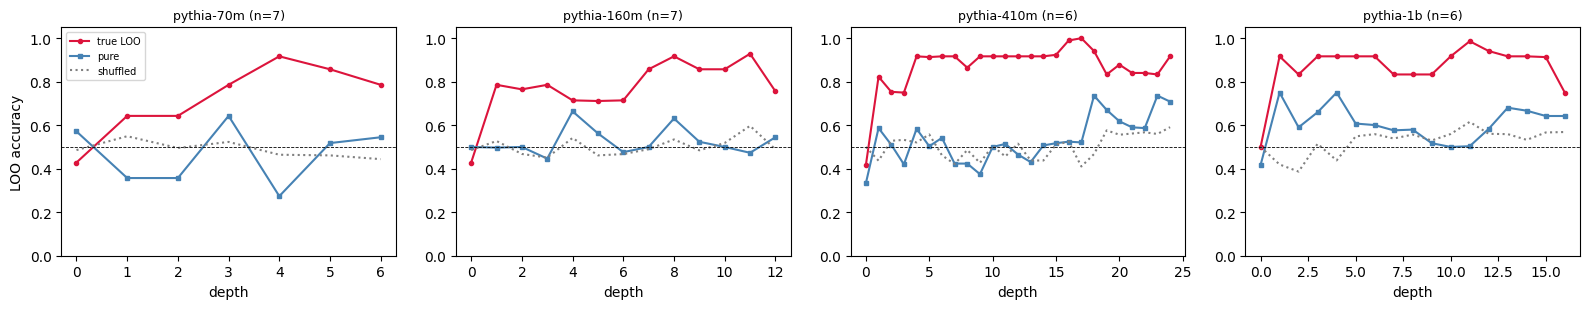

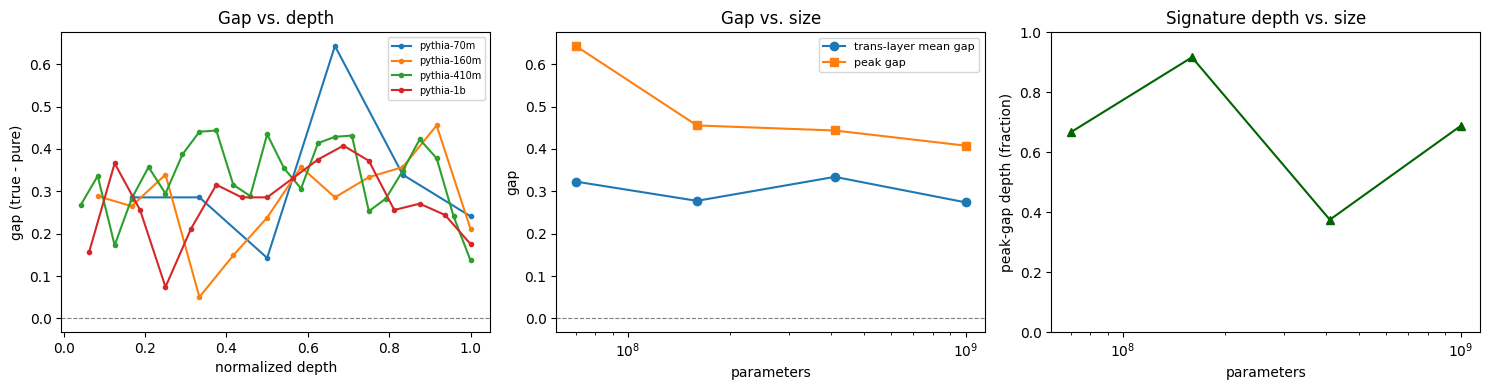

saved fig_loo_curves_by_size + fig_loo_size_scaling (.png 600dpi, .pdf)


In [8]:
# Figures (600 dpi). Fixed-7 variant is used for cross-size comparability; the screened
# variant is shown in the per-model panels.
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['savefig.dpi'] = 600

def pick(r):
    return r['fixed7'] if r.get('fixed7') else r['screened']

# Figure 1: per-model true/pure/shuffled LOO curves (screened keys where available)
names = list(RESULTS)
fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 3.2), squeeze=False)
for ax, name in zip(axes[0], names):
    r = RESULTS[name]
    a = r['screened'] or r['fixed7']
    D = r['n_depths']
    xs = list(range(D))
    ax.plot(xs, a['true'], color='crimson', marker='o', ms=3, label='true LOO')
    ax.plot(xs, a['pure'], color='steelblue', marker='s', ms=3, label='pure')
    ax.plot(xs, a['shuffled'], color='gray', ls=':', label='shuffled')
    ax.axhline(0.5, color='black', lw=0.6, ls='--')
    ax.set_ylim(0, 1.05); ax.set_xlabel('depth'); ax.set_title(f'{name} (n={len(a["keys"])})', fontsize=9)
axes[0][0].set_ylabel('LOO accuracy'); axes[0][0].legend(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_loo_curves_by_size.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT, 'fig_loo_curves_by_size.pdf'), bbox_inches='tight')
plt.show()

# Figure 2: gap vs normalized depth, and gap / peak-depth-fraction vs size (fixed-7 variant)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name in names:
    r = RESULTS[name]; a = pick(r)
    D = r['n_depths'] - 1
    xs = [d / D for d in range(1, D + 1)]
    axes[0].plot(xs, a['gap'][1:], marker='o', ms=3, label=name)
axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].set_xlabel('normalized depth'); axes[0].set_ylabel('gap (true - pure)')
axes[0].set_title('Gap vs. depth'); axes[0].legend(fontsize=7)

sizes = [PARAMS[n] for n in names]
means = [pick(RESULTS[n])['trans_gap_mean'] for n in names]
peaks = [pick(RESULTS[n])['peak_gap'] for n in names]
fracs = [pick(RESULTS[n])['peak_depth_frac'] for n in names]
axes[1].semilogx(sizes, means, marker='o', label='trans-layer mean gap')
axes[1].semilogx(sizes, peaks, marker='s', label='peak gap')
axes[1].axhline(0, color='gray', lw=0.8, ls='--')
axes[1].set_xlabel('parameters'); axes[1].set_ylabel('gap')
axes[1].set_title('Gap vs. size'); axes[1].legend(fontsize=8)

axes[2].semilogx(sizes, fracs, marker='^', color='darkgreen')
axes[2].set_ylim(0, 1); axes[2].set_xlabel('parameters')
axes[2].set_ylabel('peak-gap depth (fraction)')
axes[2].set_title('Signature depth vs. size')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_loo_size_scaling.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT, 'fig_loo_size_scaling.pdf'), bbox_inches='tight')
plt.show()
print('saved fig_loo_curves_by_size + fig_loo_size_scaling (.png 600dpi, .pdf)')


## Reporting notes

Report per size: number of screened sequences, trans-layer mean gap, peak gap, and
peak-depth fraction, on both the screened-key and fixed-7-key variants (the fixed-key variant
is the size-comparable one; the screened variant is the protocol-faithful one). If the shuffled
null deviates from 0.5 by more than about 0.05 at any depth, flag it. Interpret depth
placement (early / mid / late fraction) across sizes; this is the direct answer to reviewer
Reviewer 1's question about where the signature lies as size grows. Do not claim monotonic trends
unless they hold across all sizes run.
